In [1]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\Sohan\AppData\Local\Temp\ipykernel_20192\1848716590.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_Agent"

In [3]:
api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [4]:
result = arxiv.invoke("Attention is all you need")
print(result)

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [5]:
api_wrapper_wiki = WikipediaAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [6]:
# Custom functions
def multiply(a:int, b: int) -> int:
    """Multiply a and b
    Args:
        a: first int
        b: second int
    """
    return a*b

def add(a:int, b: int) -> int:
    """Add a and b
    Args:
        a: first int
        b: second int
    """
    return a+b

def divide(a:int, b: int) -> float:
    """Divide a and b
    Args:
        a: first int
        b: second int
    """
    return a/b

def substract(a:int, b: int) -> int:
    """Substract a and b
    Args:
        a: first int
        b: second int
    """
    return a-b

In [7]:
tavily = TavilySearchResults()

C:\Users\Sohan\AppData\Local\Temp\ipykernel_20192\2290291758.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tools = [arxiv, wiki, tavily, add, multiply, divide, substract]

In [9]:
# Bind tools to LLM
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm_with_tools = llm.bind_tools(tools)

In [10]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI new?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'p0yr4ae5b', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 888, 'total_tokens': 908, 'completion_time': 0.047469997, 'completion_tokens_details': None, 'prompt_time': 0.048287401, 'prompt_tokens_details': None, 'queue_time': 0.054527728, 'total_time': 0.095757398}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0cc1-5214-7e91-a441-aba23778519e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'p0yr4ae5b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 888, 'output_tokens': 20, 'total_tokens': 908})

In [11]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI new?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '5c9p58z9j',
  'type': 'tool_call'}]

In [12]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

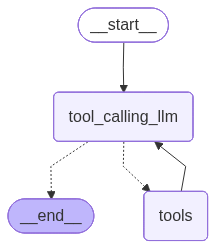

In [13]:
# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm") # This is ReAct Agent Architecture

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
messages = graph.invoke({"messages": HumanMessage(content="Provide me top 5 recent AI news, then add 5 plus 5 and then multiply by 20.")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Provide me top 5 recent AI news, then add 5 plus 5 and then multiply by 20.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (12d1feh4f)
 Call ID: 12d1feh4f
  Args:
    query: recent AI news
  add (ejxnt1s0t)
 Call ID: ejxnt1s0t
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com", "content": "Retail & Logistics AI\n\nJune 11, 2026\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n#### Industries\n\n### Omio scales travel product development using OpenAI models\n\nAI in Action\n\nJune 23, 2026\n\n### L’Oréal brings Maybelline virtual try-on to ChatGPT\n\nAI in

In [15]:
messages = graph.invoke({"messages": HumanMessage(content="Add 5 plus 5 and then divide by 2 and substract 3.")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 5 plus 5 and then divide by 2 and substract 3.
================================== Ai Message ==================================
Tool Calls:
  add (a840a63k5)
 Call ID: a840a63k5
  Args:
    a: 5
    b: 5
  divide (rq4gnhnkg)
 Call ID: rq4gnhnkg
  Args:
    a: 10
    b: 2
  substract (pa4kjctrt)
 Call ID: pa4kjctrt
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: divide

5.0
================================= Tool Message =================================
Name: substract

2
================================== Ai Message ==================================

The final answer is 2.


## **Agent Memory**

In [16]:
messages = graph.invoke({"messages": HumanMessage(content="What is 8+8?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 8+8?
================================== Ai Message ==================================
Tool Calls:
  add (kkg5nmwsf)
 Call ID: kkg5nmwsf
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: add

16
================================== Ai Message ==================================

The answer to 8+8 is 16.


In [17]:
messages = graph.invoke({"messages": HumanMessage(content="Divide that by 4")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Divide that by 4
================================== Ai Message ==================================
Tool Calls:
  divide (w4kxqnw58)
 Call ID: w4kxqnw58
  Args:
    a: 0
    b: 4
================================= Tool Message =================================
Name: divide

0.0
================================== Ai Message ==================================

I apologize, but I made an incorrect assumption. Since you didn't specify a number to divide by 4, I used 0 as a placeholder. Please provide the correct number you'd like to divide by 4.


## **Memory Saver**

- LangGraph can use a checkpointer to automatically save the graph state after each step.
- This built-in persistence layers gives us memory, allowing langgraph to pick up from the last stet update.
- One of the easiest checkpointers to use is the memorySaver, as in-memory key-value store for graph state.

MemorySaver is a feature in LangGraph that allows for the storage and recall of information between conversations, 
enabling the agent to learn from feedback and adapt to user preferences. It acts as a checkpoint, saving the entire state of the conversation 
to that checkpoint, and when a new call is made using the same thread_id, LangGraph loads the saved state, allowing the LLM to access the full 
conversation history when generating its response. This makes the dialogue coherent and gives the agent the ability to remember previous parts of a 
chat session. 

MemorySaver can be used with a persistent checkpointer like SqliteSaver for persistent storage across restarts, or with an in-memory checkpointer like 
MemorySaver for temporary memory. It can also be used to customize memory in LangGraph agents for better conversations. 

In summary, MemorySaver is a powerful tool in LangGraph that enables agents to have context-aware conversations and learn from user interactions, 
making them more intelligent and effective.

In [28]:
# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm") # This is ReAct Agent Architecture

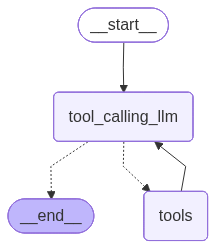

In [30]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_with_memory = builder.compile(checkpointer=memory)

# View graph
display(Image(graph_with_memory.get_graph().draw_mermaid_png()))

In [32]:
# Specify the thread
config = {"configurable": {"thread_id": "1"}}

messages = graph_with_memory.invoke({"messages": HumanMessage(content="Add 16 + 16")}, config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 16 + 16
================================== Ai Message ==================================
Tool Calls:
  add (jcsy94s8p)
 Call ID: jcsy94s8p
  Args:
    a: 16
    b: 16
================================= Tool Message =================================
Name: add

32
================================== Ai Message ==================================

The answer to 16 + 16 is 32.


In [33]:
messages = graph_with_memory.invoke({"messages": HumanMessage(content="Divide that number by 4")}, config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 16 + 16
================================== Ai Message ==================================
Tool Calls:
  add (jcsy94s8p)
 Call ID: jcsy94s8p
  Args:
    a: 16
    b: 16
================================= Tool Message =================================
Name: add

32
================================== Ai Message ==================================

The answer to 16 + 16 is 32.
================================ Human Message =================================

Divide that number by 4
================================== Ai Message ==================================
Tool Calls:
  divide (nae5r24h2)
 Call ID: nae5r24h2
  Args:
    a: 32
    b: 4
================================= Tool Message =================================
Name: divide

8.0
================================== Ai Message ==================================

The answer to 32 divided by 4 is 8.


In [35]:
messages = graph_with_memory.invoke({"messages": HumanMessage(content="Add 42 to that number")}, config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 16 + 16
================================== Ai Message ==================================
Tool Calls:
  add (jcsy94s8p)
 Call ID: jcsy94s8p
  Args:
    a: 16
    b: 16
================================= Tool Message =================================
Name: add

32
================================== Ai Message ==================================

The answer to 16 + 16 is 32.
================================ Human Message =================================

Divide that number by 4
================================== Ai Message ==================================
Tool Calls:
  divide (nae5r24h2)
 Call ID: nae5r24h2
  Args:
    a: 32
    b: 4
================================= Tool Message =================================
Name: divide

8.0
================================== Ai Message ==================================

The answer to 32 divided by 4 is 8.
================================ Human Message ==========

In [37]:
messages = graph_with_memory.invoke({"messages": HumanMessage(content="Multiply that number by 28")}, config=config)
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 16 + 16
================================== Ai Message ==================================
Tool Calls:
  add (jcsy94s8p)
 Call ID: jcsy94s8p
  Args:
    a: 16
    b: 16
================================= Tool Message =================================
Name: add

32
================================== Ai Message ==================================

The answer to 16 + 16 is 32.
================================ Human Message =================================

Divide that number by 4
================================== Ai Message ==================================
Tool Calls:
  divide (nae5r24h2)
 Call ID: nae5r24h2
  Args:
    a: 32
    b: 4
================================= Tool Message =================================
Name: divide

8.0
================================== Ai Message ==================================

The answer to 32 divided by 4 is 8.
================================ Human Message ==========